In [1]:
###1.Performing  exploratory data analysis (EDA) :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('ToyotaCorolla - MLR.csv')

In [3]:
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [4]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [5]:
df.shape

(1436, 11)

In [6]:
df.size

15796

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [8]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [9]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

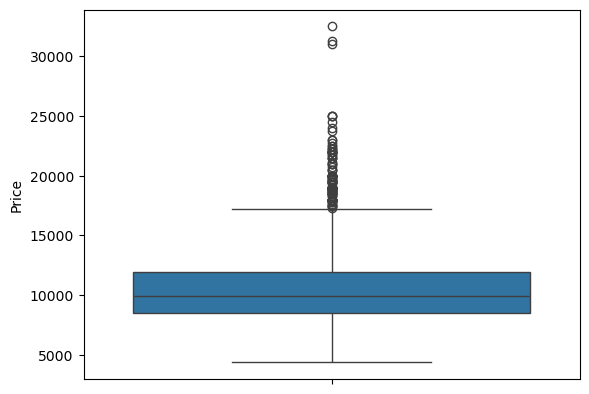

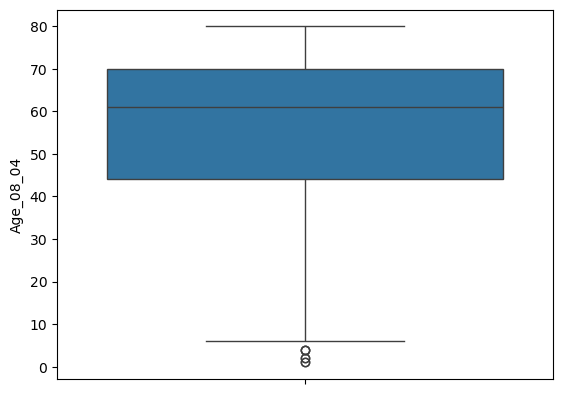

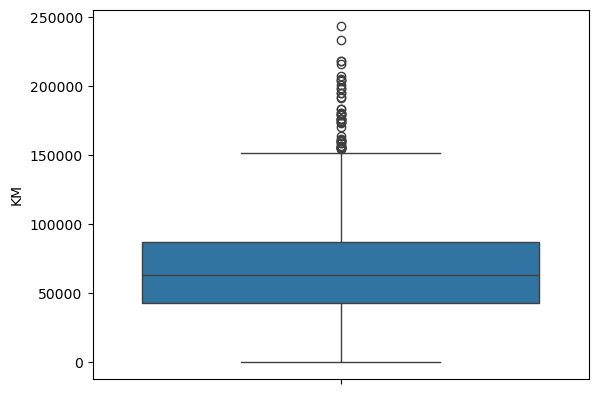

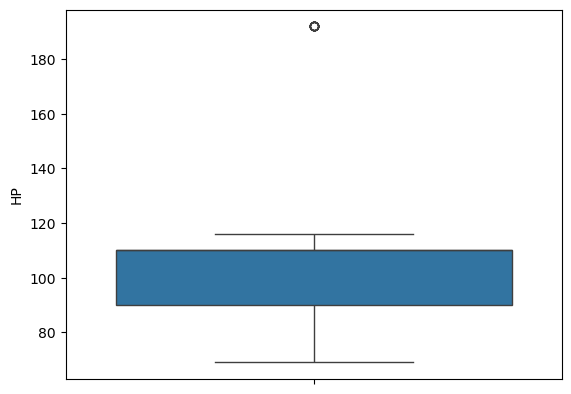

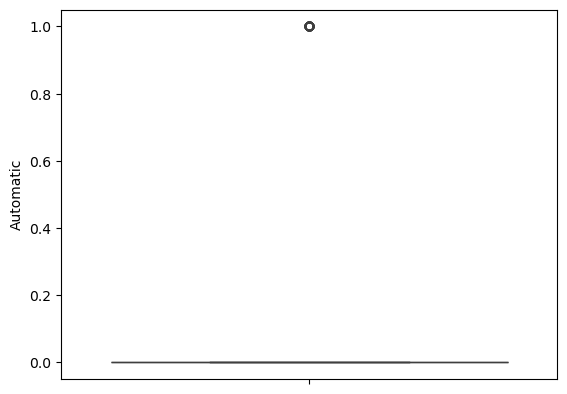

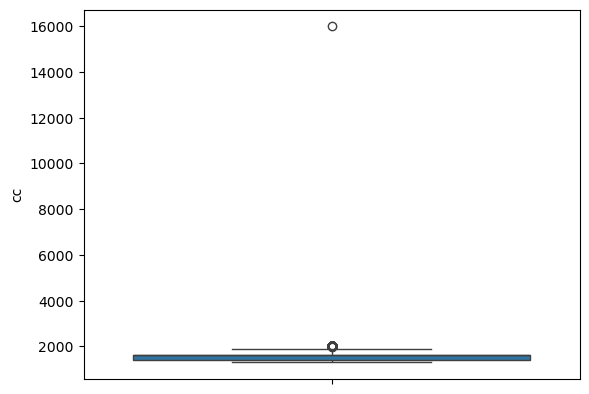

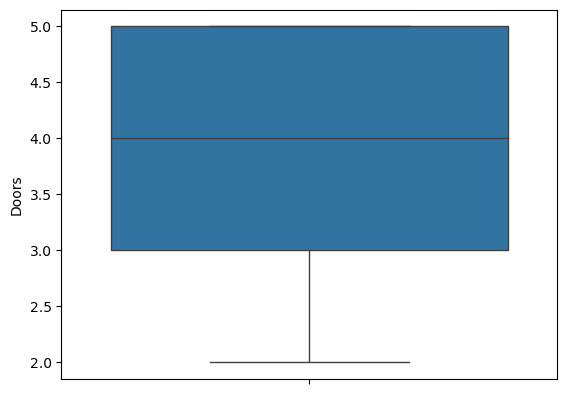

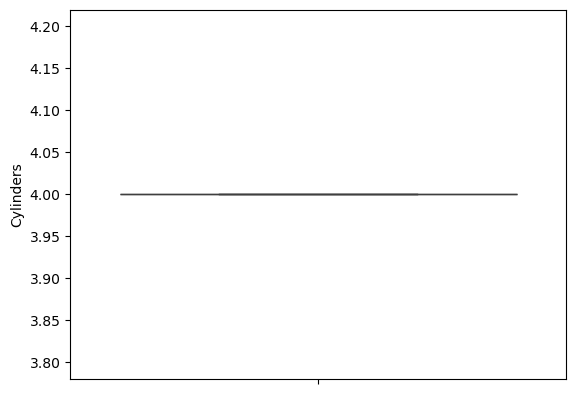

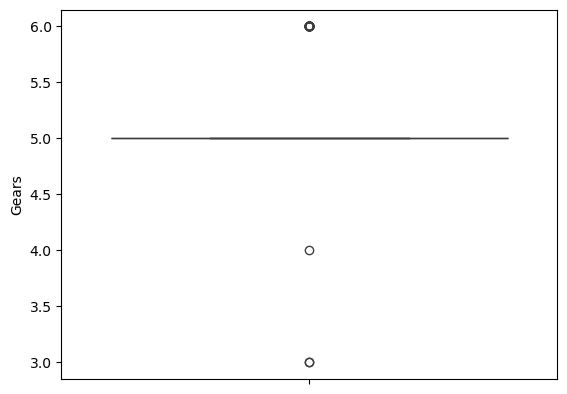

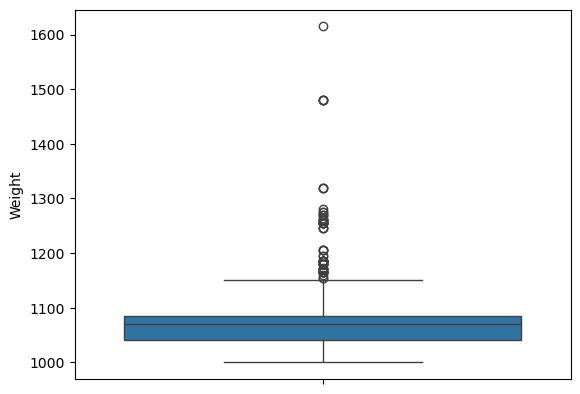

In [10]:
#Visualizations:
#Boxplot:
import seaborn as sns
import matplotlib.pyplot as plt
#Checking Boxplots
for i in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[i])
    plt.show()

In [11]:
#Outlier Capping
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    df[i]=df[i].clip(lower,upper)

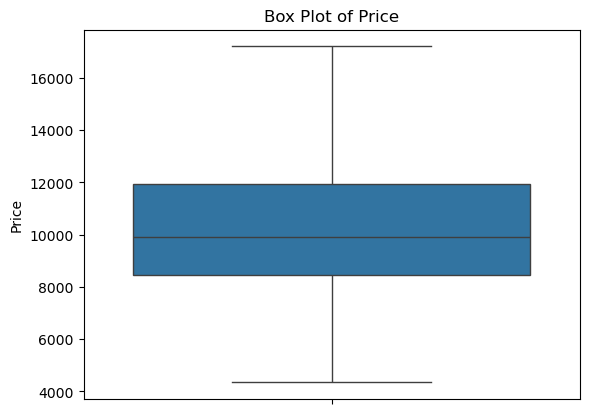

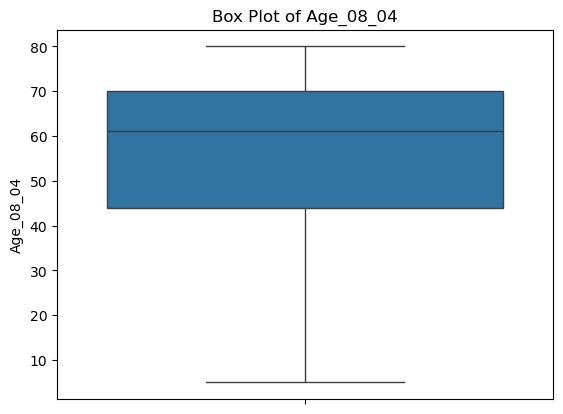

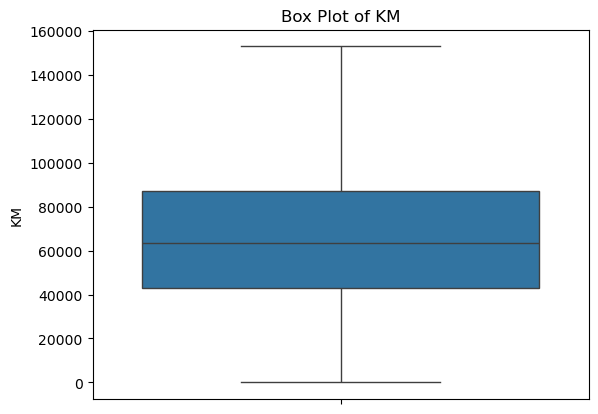

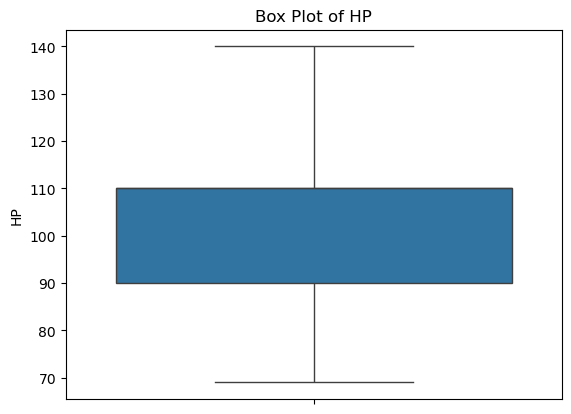

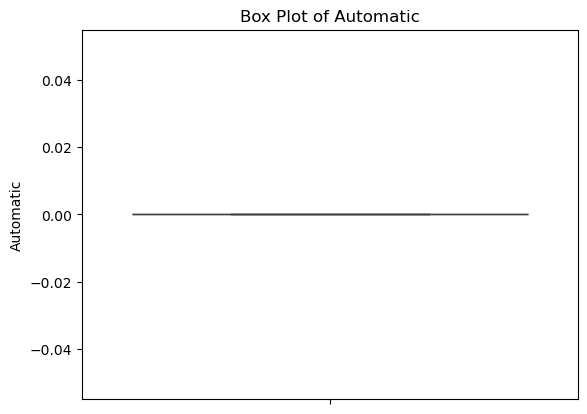

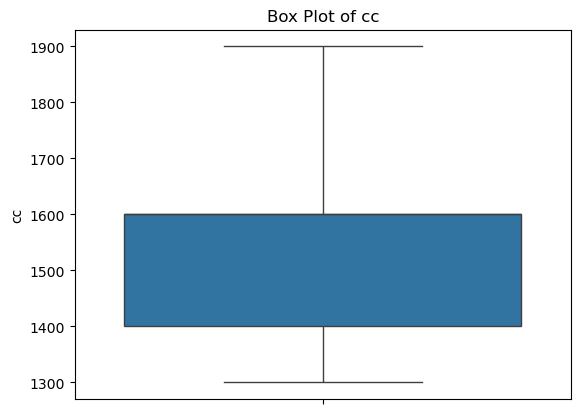

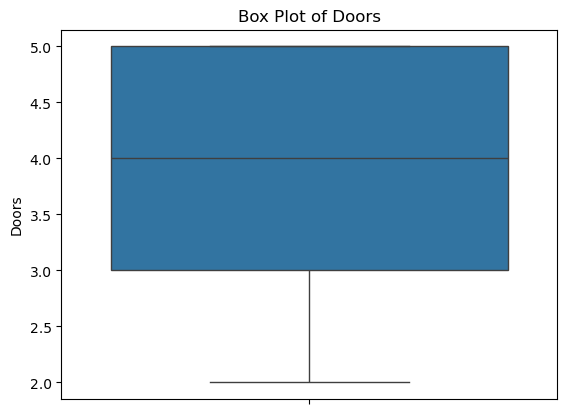

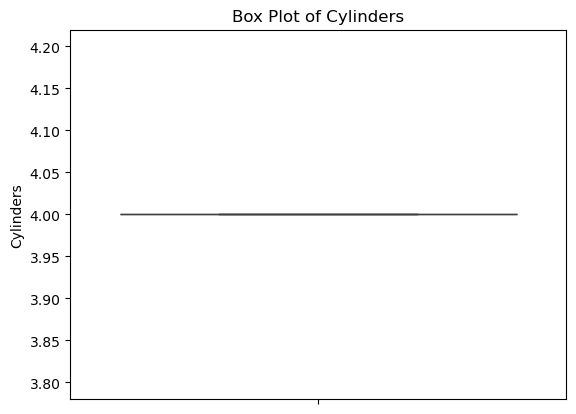

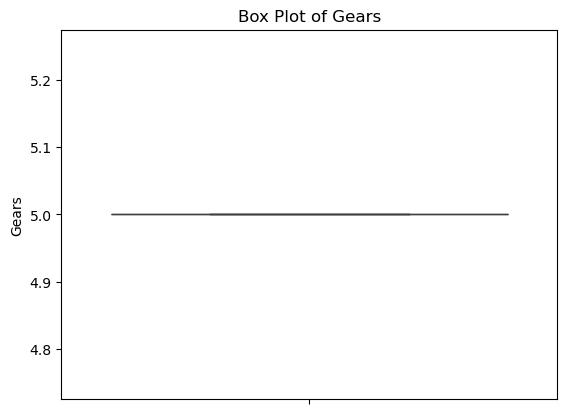

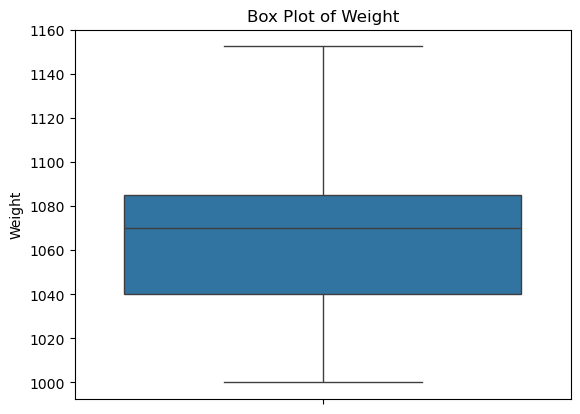

In [12]:
#Checking outliers after capping
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

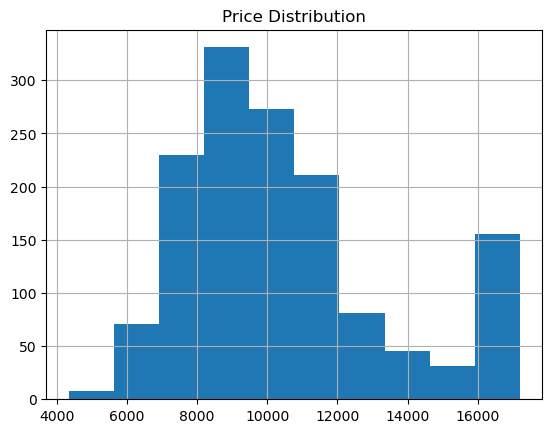

In [13]:
#Histogram:
df['Price'].hist()
plt.title('Price Distribution')
plt.show()

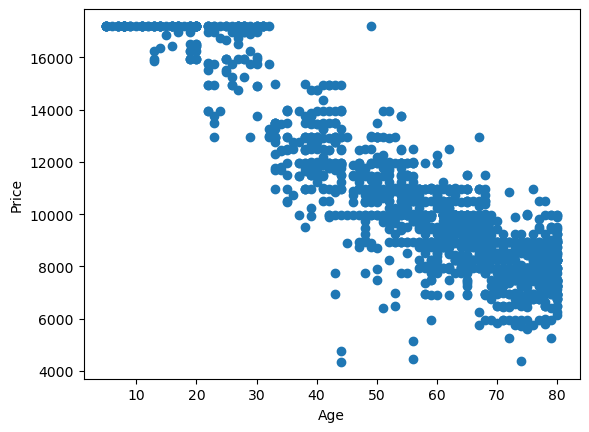

In [14]:
#ScatterPlot:
plt.scatter(df['Age_08_04'], df['Price'])
plt.xlabel('Age')
plt.ylabel('Price')
plt.show()

In [15]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [16]:


# Convert Fuel_Type into numerical columns
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)
# Convert all columns to numeric
df = df.astype(float)
# Remove columns with only one unique value
df = df.loc[:, df.nunique() > 1]
# Create input and target variables
X = df.drop('Price', axis=1)
y = df['Price']
print(X.columns)

Index(['Age_08_04', 'KM', 'HP', 'cc', 'Doors', 'Weight', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol'],
      dtype='object')


In [17]:
#2.Splitting the Dataset:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop('Price', axis=1)
y = df['Price']

In [19]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [20]:
###3:Build Minimum 3 MLR Models
##Model 1 — All features

from sklearn.linear_model import LinearRegression
model1 = LinearRegression()

model1.fit(X_train, y_train)

print("Model 1 R2:", model1.score(X_test, y_test))

Model 1 R2: 0.8626684189497995


In [21]:
###Interpret Model 1 coefficients:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model1.coef_
})
print(coefficients)

            Feature  Coefficient
0         Age_08_04  -106.420152
1                KM    -0.014325
2                HP    27.338950
3                cc    -2.501440
4             Doors   -97.690352
5            Weight    24.991727
6  Fuel_Type_Diesel  1169.504727
7  Fuel_Type_Petrol  1283.368977


In [22]:
###Model 2 — Identify the weakest feature
##P-value analysis:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
model_p = sm.OLS(y_train, X_train_sm).fit()
print(model_p.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     927.6
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:25:15   Log-Likelihood:                -9659.7
No. Observations:                1148   AIC:                         1.934e+04
Df Residuals:                    1139   BIC:                         1.938e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -9000.0825   1639.022  

In [23]:
###Find weakest feature using p-value:
p_values = model_p.pvalues
print(p_values)

const                4.922002e-08
Age_08_04           3.323835e-230
KM                   1.664111e-25
HP                   2.905135e-04
cc                   1.834164e-04
Doors                1.113611e-02
Weight               8.816159e-46
Fuel_Type_Diesel     2.115095e-02
Fuel_Type_Petrol     5.555861e-06
dtype: float64


In [24]:
weakest_feature = p_values.idxmax()
print("Weakest feature:", weakest_feature)
print("Highest p-value:", p_values.max())

Weakest feature: Fuel_Type_Diesel
Highest p-value: 0.021150950708334053


In [25]:
###VIF analysis:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif['Feature'] = X_train.columns
vif['VIF'] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]
print(vif)

            Feature          VIF
0         Age_08_04    17.101288
1                KM     9.943553
2                HP   556.987606
3                cc  1033.724027
4             Doors    21.172062
5            Weight   334.020710
6  Fuel_Type_Diesel    27.778872
7  Fuel_Type_Petrol    58.348774


In [26]:
###Model 3 — Remove weakest feature
X_train_new = X_train.drop(weakest_feature, axis=1)
X_test_new = X_test.drop(weakest_feature, axis=1)
model3 = LinearRegression()
model3.fit(X_train_new, y_train)
print("Model 3 R2:", model3.score(X_test_new, y_test))

Model 3 R2: 0.8624559719466247


In [27]:
###Coefficients of Model 3
coefficients_model3 = pd.DataFrame({
    'Feature': X_train_new.columns,
    'Coefficient': model3.coef_
})
print(coefficients_model3)

            Feature  Coefficient
0         Age_08_04  -107.103122
1                KM    -0.014751
2                HP    13.205613
3                cc    -1.311193
4             Doors  -101.375853
5            Weight    25.068677
6  Fuel_Type_Petrol   953.355992


#### INTERPRETATION ######

Negative coefficient → The variable has a negative relationship with price; an increase in the variable is associated with a decrease in predicted price, keeping other variables constant.

Positive coefficient → The variable has a positive relationship with price; an increase in the variable is associated with an increase in predicted price, keeping other variables constant.

In [28]:
#####4.Evaluate the Models:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [29]:
pred1 = model1.predict(X_test)
pred3 = model3.predict(X_test_new)
def evaluate(y_true, y_pred):
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

In [30]:
###Evaluating  all the models:
print('Model 1')
evaluate(y_test, pred1)

print('Model 3')
evaluate(y_test, pred3)

Model 1
MAE: 831.3726520676906
MSE: 1179909.602434351
R2: 0.8626684189497995
Model 3
MAE: 829.5689041085739
MSE: 1181734.8800371971
R2: 0.8624559719466247


In [31]:
####5.Ridge and Lasso:
from sklearn.linear_model import Ridge, Lasso

In [32]:
###Ridge:
ridge = Ridge(alpha=1.0) 
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test) 
print('Ridge R2:', r2_score(y_test, ridge_pred))

Ridge R2: 0.8627295342138468


In [33]:
#Lasso:
lasso = Lasso(alpha=1.0) 
lasso.fit(X_train, y_train) 
lasso_pred = lasso.predict(X_test) 
print('Lasso R2:', r2_score(y_test, lasso_pred))

Lasso R2: 0.8627222821609348


## Interview Questions:

### 1. What is Normalization and Standardization, and how is it helpful?

* **Normalization:** Scales data to a fixed range, usually **0 to 1**.
* **Standardization:** Transforms data to have **mean = 0** and **standard deviation = 1**.
* Both methods help machine learning models perform better when features have different scales.

### 2. What techniques can be used to address multicollinearity in multiple linear regression?

* Remove highly correlated variables.
* Use **Variance Inflation Factor (VIF)** to detect multicollinearity.
* Combine correlated features.
* Apply dimensionality reduction techniques such as **PCA**.
* Use regularization methods such as **Ridge Regression**.
